In [3]:
import polars as pl

df = pl.read_csv(
    "../data/megascale.csv",
    null_values=["NA"],
    infer_schema_length=10000
)

columns_to_convert = ['dG_ML', 'ddG_ML']

df = df.with_columns(
    pl.col(columns_to_convert)
    .str.replace_all(r"[^0-9.-]", "")
    .cast(pl.Float64, strict=False)
)

df = df.select([
    "WT_name",
    "name",
    "deltaG",
    "mut_type",
    "aa_seq",
    "aa_seq_full",
])

df = df.rename(
    {
        'aa_seq': 'mutated_seq_short',
        'aa_seq_full': 'mutated_seq_full'
    })

df

WT_name,name,deltaG,mut_type,mutated_seq_short,mutated_seq_full
str,str,f64,str,str,str
"""EA|run2_0325_0005.pdb""","""EA|run2_0325_0005.pdb""",3.332126,"""wt""","""DEVTIHLGDKTIRVDGLDKELLEILKELAR…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…"
"""EA|run2_0325_0005.pdb""","""EA|run2_0325_0005.pdb_wtm""",3.399832,"""wt""","""DEVTIHLGDKTIRVDGLDKELLEILKELAR…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…"
"""EA|run2_0325_0005.pdb""","""EA|run2_0325_0005.pdb_wte""",3.315782,"""wt""","""DEVTIHLGDKTIRVDGLDKELLEILKELAR…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…"
"""EA|run2_0325_0005.pdb""","""EA|run2_0325_0005.pdb_wty""",3.272933,"""wt""","""DEVTIHLGDKTIRVDGLDKELLEILKELAR…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…"
"""EA|run2_0325_0005.pdb""","""EA|run2_0325_0005.pdb_wth""",2.570242,"""wt""","""DEVTIHLGDKTIRVDGLDKELLEILKELAR…","""SAGGSAGGSAGGSAGGDEVTIHLGDKTIRV…"
…,…,…,…,…,…
"""9AME.pdb""","""9AME.pdb_dmutv5_32I:40L_I32P:L…",-2.85014,"""I32P:L40I""","""NQASVVANQLIPINTALTLVMMRSEVVTPV…","""SAGGSAGGNQASVVANQLIPINTALTLVMM…"
"""9AME.pdb""","""9AME.pdb_dmutv5_32I:40L_I32P:L…",-3.924992,"""I32P:L40W""","""NQASVVANQLIPINTALTLVMMRSEVVTPV…","""SAGGSAGGNQASVVANQLIPINTALTLVMM…"
"""9AME.pdb""","""9AME.pdb_dmutv5_32I:40L_I32P:L…",-2.365774,"""I32P:L40Y""","""NQASVVANQLIPINTALTLVMMRSEVVTPV…","""SAGGSAGGNQASVVANQLIPINTALTLVMM…"


In [4]:
import polars as pl
import re
import polars as pl

df_not_wt = df.filter(pl.col('mut_type') != "wt")

MUTATION_REGEX = re.compile(r"([A-Z])(\d+)([A-Z])")

def reconstruct_original_sequence(
    mutated_seq_short: str,
    mut_type: str,
    mutated_seq_full: str
) -> str:
    if not mut_type or "wt" in mut_type.lower():
        return "-"

    index_offset = mutated_seq_full.find(mutated_seq_short)
    if index_offset == -1:
        return "-"

    mutations = mut_type.split(":")
    reverted_seq = mutated_seq_full


    for mutation in mutations:
        match = MUTATION_REGEX.match(mutation)
        if not match:
            # Formát mutace je neplatný
            return "-"

        original_aa, position_str, mutated_aa = match.groups() # Novou (mutovanou) AMK nepotřebujeme

        if original_aa == mutated_aa:
            continue
        position = int(position_str)

        # Výpočet absolutního 0-based indexu v plné sekvenci
        # pozice - 1 (pro 0-based index) + posun
        absolute_index = position - 1 + index_offset

        # Ošetření, pokud je index mimo platný rozsah sekvence
        if not (0 <= absolute_index < len(reverted_seq)):
            return "-"

        # Provedení reverze: na daném indexu nahradíme aminokyselinu tou původní.
        reverted_seq = (
            reverted_seq[:absolute_index] +
            original_aa +
            reverted_seq[absolute_index + 1:]
        )

    if reverted_seq == mutated_seq_full:
        return "-"
    return reverted_seq


df_not_wt = df_not_wt.with_columns(
    pl.struct(['mut_type', 'mutated_seq_full', "mutated_seq_short"])
    .map_elements(
        lambda row: reconstruct_original_sequence(row['mutated_seq_short'], row['mut_type'], row['mutated_seq_full']),
        return_dtype=pl.String)
    # Výsledek uložíme do nového sloupce 'mutated_seq'
    .alias('original_seq_full'),

)

df_not_wt = df_not_wt.select(['name', 'WT_name', 'mut_type', 'mutated_seq_full', 'original_seq_full', "deltaG", "mutated_seq_short"])


LINKER_OFFSET = 0

def calculate_multi_mutation_code(struct):
    """
    Porovná WT a MUT sekvenci a vrátí string všech mutací oddělených dvojtečkou.
    Např.: "D1Q:K5R"
    """
    wt = struct['wt']
    mut = struct['mut']

    # 1. Pokud jsou identické -> WT
    if wt == mut:
        return "WT"

    # 2. Kontrola délky (pro jednoduchost předpokládáme substituce)
    if len(wt) != len(mut):
        # Pokud se délky liší, je to inzerce/delece.
        # Zde vracíme speciální značku, nebo bychom museli implementovat alignment.
        return "INDEL_OR_LEN_MISMATCH"

    mutations = []

    # 3. Iterace přes celou sekvenci
    # zip() nám umožní jít po obou sekvencích naráz
    for i, (aa_wt, aa_mut) in enumerate(zip(wt, mut)):
        if aa_wt != aa_mut:
            # Výpočet pozice:
            # (i + 1) převede 0-based index na 1-based (biologický)
            # (- LINKER_OFFSET) odečte linker na začátku
            pos = (i + 1) - LINKER_OFFSET

            # Sestavení kódu mutace: Původní + Pozice + Nová
            mutation_str = f"{aa_wt}{pos}{aa_mut}"
            mutations.append(mutation_str)

    # 4. Spojení všech nalezených mutací dvojtečkou
    if not mutations:
        return "WT" # Fallback, kdyby se nenašlo nic

    return ":".join(mutations)


df_not_wt = df_not_wt.with_columns(
    pl.struct([
        pl.col("original_seq_full").alias("wt"),
        pl.col("mutated_seq_full").alias("mut")
    ])
    .map_elements(calculate_multi_mutation_code, return_dtype=pl.String)
    .alias("mut_type")
)


# Přejmenování sloupce 'aa_seq' pro lepší srozumitelnost

df_not_wt

name,WT_name,mut_type,mutated_seq_full,original_seq_full,deltaG,mutated_seq_short
str,str,str,str,str,f64,str
"""EA|run2_0325_0005.pdb_D1Q""","""EA|run2_0325_0005.pdb""","""D13Q""","""SAGGSAGGSAGGQEVTIHLGDKTIRVDGLD…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…",3.242632,"""QEVTIHLGDKTIRVDGLDKELLEILKELAR…"
"""EA|run2_0325_0005.pdb_D1E""","""EA|run2_0325_0005.pdb""","""D13E""","""SAGGSAGGSAGGEEVTIHLGDKTIRVDGLD…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…",3.247267,"""EEVTIHLGDKTIRVDGLDKELLEILKELAR…"
"""EA|run2_0325_0005.pdb_D1N""","""EA|run2_0325_0005.pdb""","""D13N""","""SAGGSAGGSAGGNEVTIHLGDKTIRVDGLD…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…",3.269113,"""NEVTIHLGDKTIRVDGLDKELLEILKELAR…"
"""EA|run2_0325_0005.pdb_D1H""","""EA|run2_0325_0005.pdb""","""D13H""","""SAGGSAGGSAGGHEVTIHLGDKTIRVDGLD…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…",3.234823,"""HEVTIHLGDKTIRVDGLDKELLEILKELAR…"
"""EA|run2_0325_0005.pdb_D1R""","""EA|run2_0325_0005.pdb""","""D13R""","""SAGGSAGGSAGGREVTIHLGDKTIRVDGLD…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…",2.912039,"""REVTIHLGDKTIRVDGLDKELLEILKELAR…"
…,…,…,…,…,…,…
"""9AME.pdb_dmutv5_32I:40L_I32P:L…","""9AME.pdb""","""I40P:L48I""","""SAGGSAGGNQASVVANQLIPINTALTLVMM…","""SAGGSAGGNQASVVANQLIPINTALTLVMM…",-2.85014,"""NQASVVANQLIPINTALTLVMMRSEVVTPV…"
"""9AME.pdb_dmutv5_32I:40L_I32P:L…","""9AME.pdb""","""I40P:L48W""","""SAGGSAGGNQASVVANQLIPINTALTLVMM…","""SAGGSAGGNQASVVANQLIPINTALTLVMM…",-3.924992,"""NQASVVANQLIPINTALTLVMMRSEVVTPV…"
"""9AME.pdb_dmutv5_32I:40L_I32P:L…","""9AME.pdb""","""I40P:L48Y""","""SAGGSAGGNQASVVANQLIPINTALTLVMM…","""SAGGSAGGNQASVVANQLIPINTALTLVMM…",-2.365774,"""NQASVVANQLIPINTALTLVMMRSEVVTPV…"


In [5]:
df_wt = df.filter(pl.col('name') == pl.col('WT_name')).filter(pl.col('mut_type') == 'wt')
df_wt

WT_name,name,deltaG,mut_type,mutated_seq_short,mutated_seq_full
str,str,f64,str,str,str
"""EA|run2_0325_0005.pdb""","""EA|run2_0325_0005.pdb""",3.332126,"""wt""","""DEVTIHLGDKTIRVDGLDKELLEILKELAR…","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…"
"""EA|run3_0321_0005.pdb""","""EA|run3_0321_0005.pdb""",3.322303,"""wt""","""HDVTIHAGDKTIHVHGASEEFLRIIEQAKR…","""SAGGSAGGSAGGHDVTIHAGDKTIHVHGAS…"
"""EA|run3_0525_0006.pdb""","""EA|run3_0525_0006.pdb""",3.717377,"""wt""","""SHFELRVGTITLHFDNISEELAEELEKLAK…","""SAGGSAGGSAGGSHFELRVGTITLHFDNIS…"
"""EA|run3_1140_0005.pdb""","""EA|run3_1140_0005.pdb""",3.926922,"""wt""","""FHVTIHVGDITFHIHGVSEEEVKKLEELVR…","""SAGGSAGGSAGGFHVTIHVGDITFHIHGVS…"
"""EA|run5_0050_0004.pdb""","""EA|run5_0050_0004.pdb""",4.381241,"""wt""","""TEVDLHLGDITIKLKDVSEEIVKRAKELFK…","""SAGGSAGGSAGGTEVDLHLGDITIKLKDVS…"
…,…,…,…,…,…
"""2KT8.pdb""","""2KT8.pdb""",5.364639,"""wt""","""AEKTGIVNVSSSLNVREGASTSSKVIGSLS…","""SAGGSAAEKTGIVNVSSSLNVREGASTSSK…"
"""2KRS.pdb""","""2KRS.pdb""",6.64727,"""wt""","""MQGVVKVNSALNMRSGPGSNYGVIGTLRNN…","""SAGGMQGVVKVNSALNMRSGPGSNYGVIGT…"
"""2KYB.pdb""","""2KYB.pdb""",4.953675,"""wt""","""TGIVNVSSSLNVRSSASTSSKVIGSLSGNT…","""SAGGSAGGSAGTGIVNVSSSLNVRSSASTS…"


In [6]:
df_wt = df_wt.select(['name', 'mutated_seq_full', 'deltaG'])

df_wt = df_wt.rename(
    {
        'mutated_seq_full': 'original_seq_full',
    }
)

df = df.filter(pl.col('name') != pl.col('WT_name')).filter(pl.col('mut_type') != 'wild_type')

df_wt

name,original_seq_full,deltaG
str,str,f64
"""EA|run2_0325_0005.pdb""","""SAGGSAGGSAGGDEVTIHLGDKTIRVDGLD…",3.332126
"""EA|run3_0321_0005.pdb""","""SAGGSAGGSAGGHDVTIHAGDKTIHVHGAS…",3.322303
"""EA|run3_0525_0006.pdb""","""SAGGSAGGSAGGSHFELRVGTITLHFDNIS…",3.717377
"""EA|run3_1140_0005.pdb""","""SAGGSAGGSAGGFHVTIHVGDITFHIHGVS…",3.926922
"""EA|run5_0050_0004.pdb""","""SAGGSAGGSAGGTEVDLHLGDITIKLKDVS…",4.381241
…,…,…
"""2KT8.pdb""","""SAGGSAAEKTGIVNVSSSLNVREGASTSSK…",5.364639
"""2KRS.pdb""","""SAGGMQGVVKVNSALNMRSGPGSNYGVIGT…",6.64727
"""2KYB.pdb""","""SAGGSAGGSAGTGIVNVSSSLNVRSSASTS…",4.953675


In [7]:

# df_joined = df_not_wt.join(df_wt, left_on='WT_name', right_on='name', how='left', suffix='_wt')
df_joined = df_not_wt.join(df_wt, left_on='original_seq_full', right_on='original_seq_full', how='left', suffix='_wt')

# group by mut_type and avg the dg
df_joined = df_joined.group_by("mutated_seq_full").agg(
    pl.col("deltaG").mean().alias("deltaG"),
    pl.col("deltaG_wt").mean().alias("deltaG_wt"),
    pl.col("original_seq_full").first().alias("original_seq_full"),
    #  pl.col("original_seq_full_wt").first().alias("original_seq_full_wt"),
    pl.col("mut_type").first().alias("mut_type"),
)

df_joined = df_joined.with_columns(
    (pl.col('deltaG') - pl.col('deltaG_wt')).alias('ddG')
)

df_joined.drop_nulls(subset=['ddG'])

df_joined = df_joined.select([

    # 'original_seq_full_wt',

    'original_seq_full', 'mutated_seq_full', 'deltaG', 'deltaG_wt', 'ddG', 'mut_type'
])

df_joined = df_joined.drop_nulls(["ddG"])
df_joined = df_joined.filter(pl.col('original_seq_full') != '-')


df_joined.write_parquet("datasets/megascale_dataset_with_ddg.parquet")

df_joined


original_seq_full,mutated_seq_full,deltaG,deltaG_wt,ddG,mut_type
str,str,f64,f64,f64,str
"""GGITGDVSAANKDAIRKQMDAAASKGDVET…","""GGITGDVSAANKDAIRKQMDAAASKGDVET…",-0.691482,1.16441,-1.855892,"""Y31P"""
"""SAGGSEFTQISGYVNAFGSQRGSVLTVKVE…","""SAGGSEFTQISGYVNAFGSQRGSVHTVKVE…",-4.630889,1.703911,-6.3348,"""L25H:V57P"""
"""SAGGSAGGSALRDDEYDEWQDIIRDWRKEM…","""SAGGSAGGSALRDDEYDLWQDIIRDWRKEM…",0.262727,3.908905,-3.646178,"""E18L:Y54D"""
"""SAGGSPEVQIAILTEQINNLNEHLRVHKKD…","""SAGGSPQVQIAILTEQINNLNEHLRVHKKD…",1.932703,2.674476,-0.741773,"""E7Q"""
"""GQTIHNGDQTYHYDNPEEAIKVAQKLAKIY…","""GQTIHNIDQTYHYDNPEEAIKVAQKLAKIY…",1.46799,1.529946,-0.061956,"""G7I"""
…,…,…,…,…,…
"""SAGGNQASVVANTLIPINTALTLVMMRSEV…","""SAGGNQASVVANTLIPINTALTLVMMRSEV…",5.973451,6.20524,-0.231789,"""S46W"""
"""SAGGSAGTGIVNVSSSLNVRSSASTSSKVI…","""SAGGSAGTGIVNVSSSLNVRSSASTSSSVI…",2.993401,3.155036,-0.161636,"""K28S"""
"""GGITGDVSAANKDAIRKQMDAAASKGDVET…","""GGITGDVSAANKDAIRKQMDAAASKGDVET…",1.23246,1.16441,0.06805,"""K39R"""


In [8]:
# join back and campute ddg (just the difference)

# join WT_name to name in df_wt

df_joined = df_not_wt.join(df_wt, left_on='WT_name', right_on='name', how='left', suffix='_wt')
# df_joined = df_not_wt.join(df_wt, left_on='original_seq_full', right_on='original_seq_full', how='left', suffix='_wt')


# group by mut_type and avg the dg
df_joined = df_joined.group_by("mutated_seq_full").agg(
    pl.col("deltaG").mean().alias("deltaG"),
    pl.col("deltaG_wt").mean().alias("deltaG_wt"),
    pl.col("original_seq_full").first().alias("original_seq_full"),
    pl.col("original_seq_full_wt").first().alias("original_seq_full_wt"),
    pl.col("mut_type").first().alias("mut_type"),
)

df_joined = df_joined.with_columns(
    (-pl.col('deltaG') + pl.col('deltaG_wt')).alias('ddG')
)

df_joined.drop_nulls(subset=['ddG'])

df_joined = df_joined.select([

    'original_seq_full_wt',
    'original_seq_full', 'mutated_seq_full', 'deltaG', 'deltaG_wt', 'ddG', 'mut_type'
])

df_joined.filter(pl.col('mut_type') != 'wild_type').filter(
    pl.col('original_seq_full_wt') == pl.col('original_seq_full'))

df_joined = df_joined.drop_nulls(["ddG"])
df_joined = df_joined.filter(pl.col('original_seq_full') != '-')


df_joined


original_seq_full_wt,original_seq_full,mutated_seq_full,deltaG,deltaG_wt,ddG,mut_type
str,str,str,f64,f64,f64,str
"""SAGGSAGGSAGGYNLQKLLAPYHKAKTLER…","""SAGGSAGGYNLQKLLAPYHKAKTLERQVYE…","""SAGGSAGGYNLQKLLAPYHKAKTLERQVYE…",-2.171918,2.057796,4.229715,"""L38E"""
"""SAGGTYTWNTKEEAKQAFKELLKEKRVPSN…","""SAGGTYTWNTKEEAKQAFKELLKEKRVPSN…","""SAGGTYTWNTKEEAKQAFKELLKVKRVPSN…",-0.473937,2.23667,2.710607,"""E24V:D43I"""
"""SQEELVKAFKALLKEEKFSSQGEIVAALQE…","""SQEELVKAFKALLKEEKFSSQGEIVAALQE…","""SWEELVKAFKALLKEEKFSSQGEIVAALQE…",3.620786,3.432448,-0.188338,"""Q2W"""
"""SAGGNLYFQGLKYMVPGARVTRGLDWKWRD…","""NLYFQGLKYMVPGARVTRGLDWKWRDQDGS…","""NLYFQGLKYMVPGARVTRGLDWKWRDQDGS…",2.342372,3.115544,0.773173,"""L41I"""
"""SAGGSAGGSAGGKNAAQIVDEALNQGITLF…","""SAGGSAGGKNAAQIVDEALNQGITLFVADN…","""SAGGSAGGKNAAQIVDEALNQKITLFVADN…",2.174527,3.50917,1.334643,"""G22K"""
…,…,…,…,…,…,…
"""SAGGSAGGMVQRGSKVRILRPESYWFQDVG…","""SAGGMVQRGSKVRILRPESYWFQDVGTVAS…","""SAGGMVQRGSKVRILRPESYWFQDVGTVAS…",2.419448,2.280799,-0.138649,"""E59P"""
"""SAGGSAGGSAGGSAHFTSQQLQELEATFQR…","""SAGGSAGGSAHFTSQQLQELEATFQRNRYP…","""SAGGSAGGSAHFTSQQLQELEATFQRNRYP…",2.447595,2.166546,-0.28105,"""T34M"""
"""SAGGSAVTLFVALYDYEAITEDDLSFHKGE…","""SAGGSAVTLFVALYDYEAITEDDLSFHKGE…","""SAGGSAVTLFVALYDYEAITEDDLSFHKGW…",0.992407,5.028433,4.036027,"""E30W:S47P"""


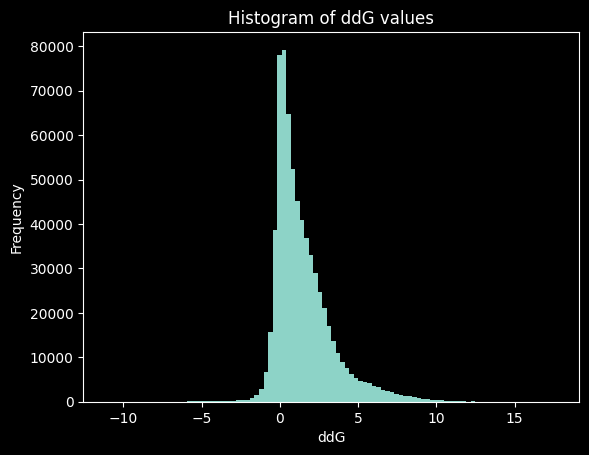

In [9]:
# hisotram of the ddG values

import matplotlib.pyplot as plt
plt.hist(df_joined['ddG'], bins=100)
plt.xlabel('ddG')
plt.ylabel('Frequency')
plt.title('Histogram of ddG values')
plt.show()

# for feature jakub, this is fine in case that more of the data is positive.